# Dimensionality reduction on the cancer dataset

Goals:
- Preprocess our raw single cell data
- Use the processed data to create a continuous latent space via PHATE.
- Understand how to interpret some of the PHATE parameters and how to choose a good representation of the space.

# Setup Instructions

First, install the required Python libraries in your Jupyter environment. 

**Important:** You must restart your Jupyter kernel after installation to ensure the libraries load properly.

pip is the is the package installer for Python.

The following libraries will be installed:

- phate - PHATE (Potential of Heat Diffusion for Affinity-based Transition Embedding) algorithm for dimensionality reduction and visualization of high-dimensional biological data

- scprep - Single Cell data Preparation toolkit providing preprocessing utilities for single-cell RNA sequencing data

- scanpy - Single-Cell Analysis in Python, a comprehensive toolkit for analyzing single-cell gene expression data

- gdown - Command-line tool and Python library for downloading files from Google Drive, useful for accessing shared datasets

- pandas - Powerful data manipulation and analysis library, essential for handling structured data in Python

After installation completes, restart your Jupyter kernel before importing these libraries in your analysis.

In [1]:
!pip install phate scprep scanpy gdown pandas==2.2.0 

## 0. Importing all the necessary packages

In [183]:
# Core scientific computing and data analysis libraries
import numpy as np          # Numerical computing library for array operations and mathematical functions
import pandas as pd         # Data manipulation and analysis library for structured data (DataFrames)
import matplotlib.pyplot as plt  # Plotting library for creating visualizations and charts
import seaborn as sns
# Single-cell analysis framework
import scanpy as sc         # Single-cell analysis toolkit for preprocessing, visualization, and analysis

# Display matplotlib plots directly in notebook cells
%matplotlib inline      

# Specialized single-cell and dimensionality reduction libraries  
import phate               # PHATE algorithm for dimensionality reduction and data visualization
import scprep              # Single-cell data preprocessing utilities and helper functions

# System and file handling libraries
import gdown               # Google Drive file downloader for accessing shared datasets

## 1. Downloading the data

First we will download the data from google drive.

Alternatively, you may load your own data by replacing the Google Drive file ids with your own file ids.

Note that if you do, you will likely not have sample labels. 
Replace all references to `'sample_labels'` with an entry from `adata.var_names`, or your favorite gene.

In [ ]:
file_id = "1VCl5Gqpa-z99t9Ve0IP_ie_JVGbiYBN2" #File id in google drive for our data
url = f"https://drive.google.com/uc?id={file_id}"
output = "data.h5ad"
gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1VCl5Gqpa-z99t9Ve0IP_ie_JVGbiYBN2
From (redirected): https://drive.google.com/uc?id=1VCl5Gqpa-z99t9Ve0IP_ie_JVGbiYBN2&confirm=t&uuid=b0d876c0-1fcf-473e-a520-185370bc28c9
To: /Users/joaofelipe/Yale/Omics Toolbox/4_Code/omics_toolbox/workshops/cancer_plasticity/phate/data.h5ad
100%|██████████| 523M/523M [00:24<00:00, 21.3MB/s] 


'data.h5ad'

In [2]:
# Now, let's read the data we downloaded. For this, we will use scanpy's read_h5ad function.
adata = sc.read_h5ad("data.h5ad")
adata

AnnData object with n_obs × n_vars = 16985 × 21465
    obs: 'n_counts', 'batch', 'day', 'new', 'sample_id', 'growth', 'log_growth', 'sample_labels', 'louvain', 'S_score', 'G2M_score', 'phase', 'emt_scores'
    var: 'gene_ids', 'feature_types', 'genome', 'n_counts', 'is_emt'
    uns: 'emt_weights', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'phase_colors', 'sample_id_colors'
    obsm: 'X_pca', 'X_phate'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

As you can see, our ```adata``` has a lot of information, but for this first tutorial, we will only care about the **gene measurements** and the **day of collection**.
Let's leave the explanation of the entire dataset in details for the next tutorial on MIOFlow.

To obtain the gene measurements, we need to access the **adata.X**. The sample_labels are under **adata.obs**

In [15]:
# Here, we transform our adata.X into a pandas DataFrame, so it is easier to manipulate.
# We just need to define which are the column names.

data = pd.DataFrame(adata.X.toarray(), index=adata.obs_names, columns=adata.var_names)
sample_labels = adata.obs['sample_id']

Now let's just see what our data look's like.

In [16]:
data

,AL627309.1,AL669831.5,FAM87B,LINC00115,FAM41C,AL645608.3,AL645608.5,AL645608.1,SAMD11,NOC2L,...,AC136616.1,BX004987.1,AC145212.1,MAFIP,AC011043.1,AL592183.1,AC007325.4,AL354822.1,AC004556.1,AC240274.1
AAACCTGAGTTCGCGC-1-4,0.0,0.0,0.0,0.0,0.0,0.881339,0.0,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCTGCAGGACCCT-1-4,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.893713,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCTGCATGTTGAC-1-4,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.960031,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCTGGTCGAACAG-1-4,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,1.094286,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCTGTCCGTTGCT-1-4,0.0,0.0,0.0,0.0,0.0,1.160205,0.0,1.160205,1.160205,1.160205,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGGTTTCCGCTGTT-1-8,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TTTGGTTTCTGCGGCA-1-8,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TTTGTCACAGTCTTCC-1-8,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.970280,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TTTGTCAGTACTTGAC-1-8,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,1.137588,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


The index in our DataFrame are each indivudual cell's barcode.
The columns are the genes we are measuring.
Take a look at the shape of our data: we have almost 17k cells and 21k gene measurements.

In [5]:
sample_labels

AAACCTGAGTTCGCGC-1-4     0
AAACCTGCAGGACCCT-1-4     0
AAACCTGCATGTTGAC-1-4     0
AAACCTGGTCGAACAG-1-4     0
AAACCTGTCCGTTGCT-1-4     0
                        ..
TTTGGTTTCCGCTGTT-1-8    30
TTTGGTTTCTGCGGCA-1-8    30
TTTGTCACAGTCTTCC-1-8    30
TTTGTCAGTACTTGAC-1-8    30
TTTGTCAGTTCCACGG-1-8    30
Name: sample_id, Length: 16985, dtype: category
Categories (5, int64): [0, 2, 12, 18, 30]

The sample_labels are the dates in which we have collected the samples in the dataset.
We have 5 categories: Day 0, 2, 12, 18 and 30.

<a id='preprocessing'></a>
## 2. Preprocessing: Filtering, Normalizing, and Transforming

As we saw, we have a lot of cells and genes. Therefore we need to remove a lot of the noise from the data by preprocessing it.
We will start by filtering the data.

We filter the data by: 
1. Filtering by library size
2. Removing genes that are expressed in relatively few cells.
3. Removing dead cells

We filter dead cells after library size normalization, since library size is not necessarily related to cell state.

#### Filtering I. Library size filtering 

Library size is the total sum of gene counts in a cell.

We filter out cells that have either very large or very small library sizes. For this data set.

In this case, we eliminate the top and bottom 10% of cells for each sample. Similar results are obtained with simpler, less conservative filtering.

/Users/joaofelipe/miniconda3/envs/omics-toolbox/lib/python3.10/site-packages/scprep/plot/utils.py:104: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


<Axes: xlabel='Library size', ylabel='Number of cells'>

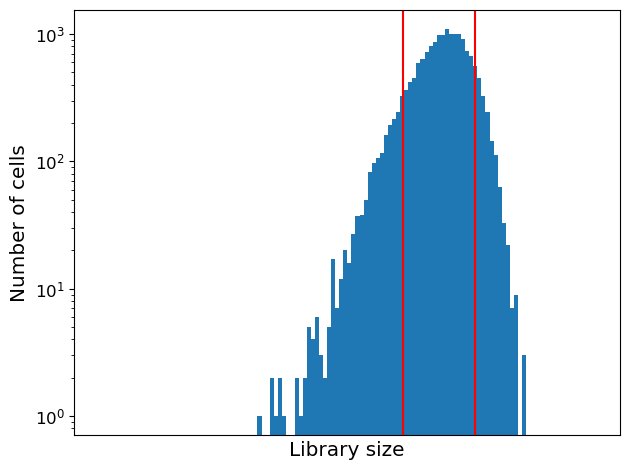

In [17]:
# Visualize the parts of the data we will drop.
# We will keep drop the bellow 10 and above 90 percentiles.
scprep.plot.plot_library_size(data, percentile=[10,90])

In [18]:
# Here you can change the percentile to remove more or less cell from processing
# Here we pass sample_labels so we can "drop" the sample labels as well.

data, sample_labels = scprep.filter.filter_library_size(data,sample_labels, percentile=10, keep_cells='above')
data, sample_labels = scprep.filter.filter_library_size(data,sample_labels, percentile=90, keep_cells='below')

Now, let's look at our data once more

In [19]:
data

,AL627309.1,AL669831.5,FAM87B,LINC00115,FAM41C,AL645608.3,AL645608.5,AL645608.1,SAMD11,NOC2L,...,AC136616.1,BX004987.1,AC145212.1,MAFIP,AC011043.1,AL592183.1,AC007325.4,AL354822.1,AC004556.1,AC240274.1
AAACCTGAGTTCGCGC-1-4,0.0,0.0,0.0,0.0,0.0,0.881339,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCTGCAGGACCCT-1-4,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.893713,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCTGCATGTTGAC-1-4,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.960031,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCTGGTCGAACAG-1-4,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,1.094286,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCTGTCCTAGAAC-1-4,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGGTTGTACCGGCT-1-8,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TTTGGTTTCAAAGTAG-1-8,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TTTGGTTTCCGCTGTT-1-8,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TTTGTCAGTACTTGAC-1-8,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,1.137588,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


As you can see, we have dropped around 3k cells.

### Filtering II. Remove rare genes

We eliminate genes that are expressed in 10 cells or fewer, they usually bring no information and increase the dimentionality of our data.

We are removing genes that appear in less than 10 cells.

In [20]:
data = scprep.filter.filter_rare_genes(data, min_cells=10)

In [21]:
data

,AL627309.1,AL669831.5,FAM87B,LINC00115,FAM41C,AL645608.3,AL645608.1,SAMD11,NOC2L,KLHL17,...,AC136616.1,BX004987.1,AC145212.1,MAFIP,AC011043.1,AL592183.1,AC007325.4,AL354822.1,AC004556.1,AC240274.1
AAACCTGAGTTCGCGC-1-4,0.0,0.0,0.0,0.0,0.0,0.881339,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCTGCAGGACCCT-1-4,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.893713,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCTGCATGTTGAC-1-4,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.960031,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCTGGTCGAACAG-1-4,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,1.094286,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCTGTCCTAGAAC-1-4,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGGTTGTACCGGCT-1-8,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.744694,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TTTGGTTTCAAAGTAG-1-8,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TTTGGTTTCCGCTGTT-1-8,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TTTGTCAGTACTTGAC-1-8,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,1.137588,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


We have dropped aroun 2k genes that were bringing almost no information.

### Normalization I. Library Size normalization

To correct for differences in library sizes, we divide each cell by its library size and then rescale by the median library size.

In python this is performed using the preprocessing method `library_size_normalize()`.

In [22]:
data = scprep.normalize.library_size_normalize(data)

In [25]:
data # Take a look in some specific genes and cell measurements. You can see that some increased.

,AL627309.1,AL669831.5,FAM87B,LINC00115,FAM41C,AL645608.3,AL645608.1,SAMD11,NOC2L,KLHL17,...,AC136616.1,BX004987.1,AC145212.1,MAFIP,AC011043.1,AL592183.1,AC007325.4,AL354822.1,AC004556.1,AC240274.1
AAACCTGAGTTCGCGC-1-4,0.0,0.0,0.0,0.0,0.0,1.792592,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCTGCAGGACCCT-1-4,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,1.839579,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCTGCATGTTGAC-1-4,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,2.149215,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCTGGTCGAACAG-1-4,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,2.529097,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCTGTCCTAGAAC-1-4,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGGTTGTACCGGCT-1-8,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,1.464681,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TTTGGTTTCAAAGTAG-1-8,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TTTGGTTTCCGCTGTT-1-8,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TTTGTCAGTACTTGAC-1-8,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,2.283109,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### Filtering III: Dead cell removal

Dead cells are likely to have a higher mitochondrial RNA expression level than live cells. Therefore, we remove suspected dead cells by eliminating cells that have the highest mitochondrial RNA expression levels on average.  

First let's look at the distribution of mitochontrial genes.

/Users/joaofelipe/miniconda3/envs/omics-toolbox/lib/python3.10/site-packages/scprep/plot/utils.py:104: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


<Axes: xlabel='Gene expression', ylabel='Number of cells'>

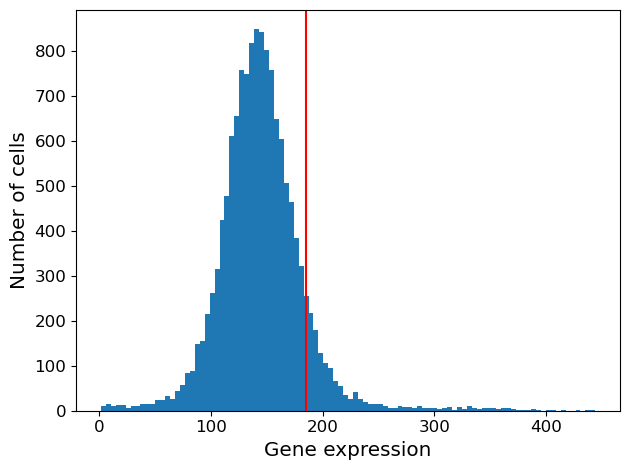

In [26]:
mito_genes = scprep.select.get_gene_set(data, starts_with="MT-") # Get all mitochondrial genes. There are 14, FYI.
scprep.plot.plot_gene_set_expression(data, genes=mito_genes, percentile=90)

Here we see that above the top 90th percentile, there is a steep increase in expression of mitochondrial RNAs. We'll remove these cells from further analysis.

In [27]:
data, sample_labels = scprep.filter.filter_gene_set_expression(
    data, sample_labels, genes=mito_genes, 
    percentile=90, keep_cells='below')

### Transformation I. Sqrt Transformation

In scRNA-seq analysis, the data is often $\log$-transformed. This typically requires the addition of some small value to avoid taking $\log(0)$. We avoid this issue entirely by instead taking the square root transform. The square root function has a similar form as the $\log$ function with the added benefit of being stable at 0.

In [28]:
data = scprep.transform.sqrt(data)

## 3. Visualization using Principle Components Analysis (PCA)

Here we're going to use the simplest dimensionality reduction method first. We don't expect PCA to work well because the dataset is so complex, but it's a good place to start with any dataset.

#### Running PCA on the cancer dataset

In [31]:
#We can use scprep to compute the pca. We will use 200 components.
data_pca = scprep.reduce.pca(data, n_components=200, method='dense')

In [33]:
data_pca

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC191,PC192,PC193,PC194,PC195,PC196,PC197,PC198,PC199,PC200
AAACCTGAGTTCGCGC-1-4,9.813943,14.656542,0.218241,3.868451,-1.304620,-0.990729,-0.665543,6.838793,0.708851,-0.963540,...,-0.025810,0.168478,-1.285949,-0.131397,-0.116201,-1.046796,-1.058727,0.351779,-1.612649,-0.243215
AAACCTGCAGGACCCT-1-4,11.983555,16.068148,3.843330,-2.071760,-3.374086,1.710464,-8.636296,-1.896097,-2.921398,-1.614470,...,-0.129568,1.991060,0.679645,-0.761009,1.411861,1.443442,-1.608375,0.970972,0.051798,0.490836
AAACCTGCATGTTGAC-1-4,-1.813683,15.971581,10.309247,0.144290,-5.248218,0.796796,1.889393,4.396223,-0.598106,4.219580,...,-0.729076,0.440400,1.733747,0.649154,0.844270,0.520637,0.335540,0.547063,-0.469378,-1.752819
AAACCTGTCCTAGAAC-1-4,9.559916,15.489783,1.884373,0.063920,6.784870,3.756032,-3.849543,-6.149530,-6.132852,4.599725,...,-1.193221,0.728349,1.538735,0.159876,-1.078673,0.034559,-0.551520,1.282093,1.162415,-1.119614
AAACCTGTCTACTATC-1-4,8.002732,16.235765,3.081550,-1.623192,-2.592666,-3.766258,-4.424612,4.682780,3.992908,0.673478,...,0.818427,-0.284174,-1.925964,0.972577,0.977082,-1.855090,0.733141,0.283957,-0.446262,0.092001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGCGCTCCAGAAGG-1-8,-17.122322,4.407327,-0.184049,11.937760,-2.166286,-2.447874,0.869300,1.692863,-2.127437,1.391577,...,-0.294917,-0.231934,-0.045450,-0.680944,0.354880,-1.280282,0.374766,-0.080737,-0.361078,-0.425764
TTTGGTTAGATGTGGC-1-8,-23.768251,4.166601,-0.157182,5.289539,5.971056,-1.215425,1.043538,1.407926,2.930237,2.210233,...,-1.153189,0.017440,0.108660,0.595479,0.384146,-0.562890,-1.640059,0.978568,0.850005,-0.499878
TTTGGTTGTACCGGCT-1-8,-19.044313,-0.449929,-3.901196,8.154789,-0.064875,-1.206587,-1.969369,1.071396,0.883225,-2.319990,...,-0.586130,-0.519989,0.068093,-0.799722,-1.683785,0.021511,0.242987,-0.464443,0.071812,-0.004614
TTTGGTTTCAAAGTAG-1-8,-22.020142,4.364420,-1.056956,5.220803,4.494550,-1.745723,2.783673,-1.712113,4.521574,1.095743,...,-0.047441,1.450755,-2.495023,0.270801,0.014544,-1.456929,-0.351118,0.266374,0.650855,-0.764077


As you can see, each cell is now represented by 200 dimensions, not the 19k we needed before

#### Plotting PCs using `scprep.plot`

The scprep package has a number of handy plotting features that act as a wrapper to `matplotlib`. You should know how to use `matplotlib` for more complicated plotting, but you can make all the plots we need in this tutorial with some help from `scprep`.

The full documentaiton of `scprep.plot` can be found here:

https://scprep.readthedocs.io/en/stable/reference.html#module-scprep.plot

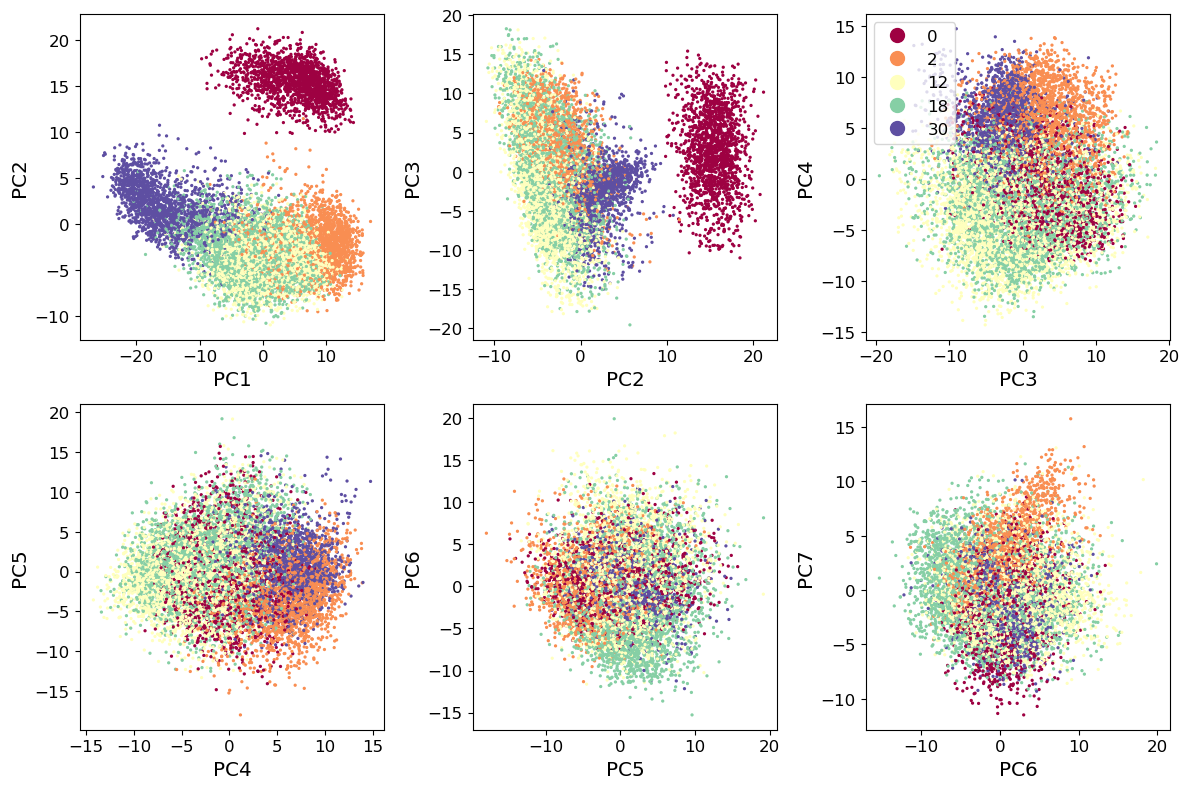

In [40]:
# Create a figure (the background) and a set of axes (the things we plot on)
fig, axes = plt.subplots(2,3, figsize=(12,8))
# This makes it easier to iterate through the axes
axes = axes.flatten()

for i, ax in enumerate(axes):
    # only plot a legend on one axis
    legend = True if i == 2 else False
    # There are a lot of parameters here, you can find the full scatter documentation at
    # https://scprep.readthedocs.io/en/stable/reference.html#scprep.plot.scatter
    scprep.plot.scatter(data_pca.iloc[:,i], data_pca.iloc[:,i+1], 
                        c=sample_labels,
                        cmap='Spectral', ax=ax,
                        # label_prefix="PC", 
                        legend=legend)
fig.tight_layout()

#### Plotting expression of a gene on the first two PCs

Now let's plot expression of some genes!


/Users/joaofelipe/miniconda3/envs/omics-toolbox/lib/python3.10/site-packages/scprep/plot/utils.py:104: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


<Axes: title={'center': 'ZEB1'}, xlabel='PC1', ylabel='PC2'>

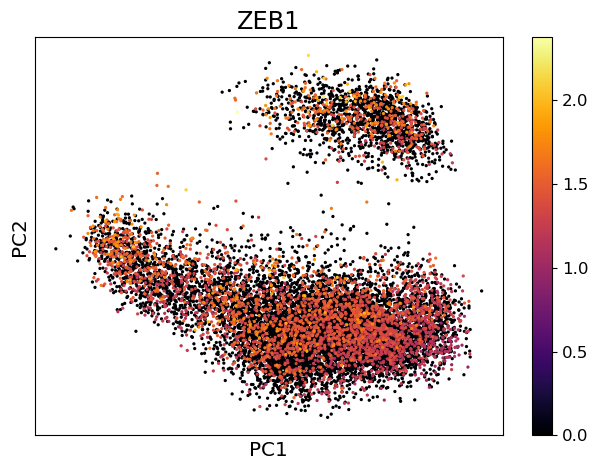

In [41]:
gene = 'ZEB1'

expression = scprep.select.select_cols(data, exact_word=gene)

# we will sort cells by maximum expression so we can see where the gene is expressed
sort_index = expression.sort_values().index

scprep.plot.scatter2d(data_pca.loc[sort_index], c=expression.loc[sort_index], shuffle=False,
                     title=gene, ticks=None, label_prefix='PC')

/Users/joaofelipe/miniconda3/envs/omics-toolbox/lib/python3.10/site-packages/scprep/plot/utils.py:104: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


<Axes: title={'center': 'CD44'}, xlabel='PC1', ylabel='PC2'>

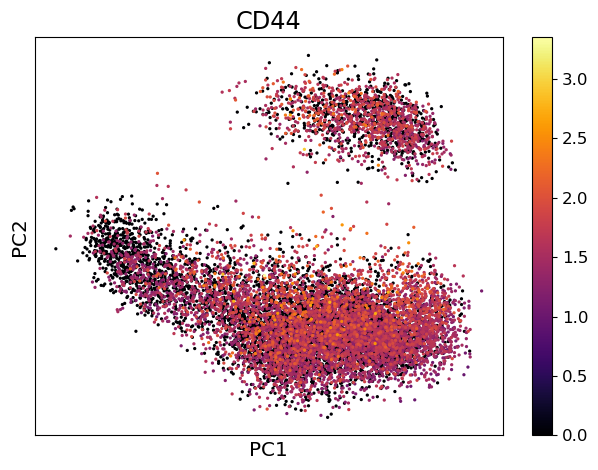

In [42]:
gene = 'CD44'

# ================
# Sort cells by maximum expression of CD44 and plot the result on PCA
expression = scprep.select.select_cols(data, exact_word=gene)

sort_index = expression.sort_values().index

scprep.plot.scatter2d(data_pca.loc[sort_index], c=expression.loc[sort_index], shuffle=False,
                     title=gene, ticks=None, label_prefix='PC')
# ===============

/Users/joaofelipe/miniconda3/envs/omics-toolbox/lib/python3.10/site-packages/scprep/plot/utils.py:104: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


<Axes: title={'center': 'ACTB'}, xlabel='PC1', ylabel='PC2'>

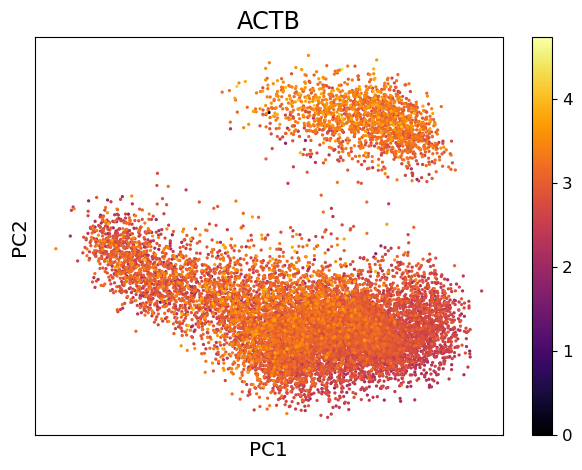

In [46]:
gene = 'ACTB' #(Beta-Actin)

# ================
# Sort cells by maximum expression of HAND1 and plot the result on PCA
expression = scprep.select.select_cols(data, exact_word=gene)

sort_index = expression.sort_values().index

scprep.plot.scatter2d(data_pca.loc[sort_index], c=expression.loc[sort_index], shuffle=False,
                     title=gene, ticks=None, label_prefix='PC')
# ===============

### Discussion

1. Why did we plot gene expression on the first two PCs?

The first two PCs represents the highest level structure of the data, so gene expression plotted on this gives us a broad understanding of what's happening in the data. The genes allows us to characterize each part of the manifold.

2. Look up the function of these genes. What do you notice about where these genes are expressed? What does it mean when a gene is expressed everywhere vs. in one region?

If a gene is expressed everywhere, it is likely some kind of housekeeping gene (indeed, Beta-actin is a part of the cell cytoskeleton and is expressed in all human cells.) 

If a gene is only expression in one region, it's likely to be cell-type specific, like HAND1 which is a heart / neural crest marker.

## 4. Embedding Data Using PHATE

#### How does PHATE work?

PHATE is a dimensionaltiy reduction developed by the Krishnaswamy lab for visualizing high-dimensional data. We use PHATE for *every* dataset the comes through the lab: scRNA-seq, CyTOF, gut microbiome profiles, simulated data, etc. PHATE was designed to handle noisy, non-linear relationships between data points. PHATE produces a low-dimensional representation that preserves both local and global structure in a dataset so that you can make generate hypotheses from the plot about the relationships between cells present in a dataset. Although PHATE has utility for analysis of many data modalities, we will focus on the application of PHATE for scRNA-seq analysis.

PHATE is inspired by diffusion maps [(Coifman et al. 2008.)](https://doi.org/10.1016/j.acha.2006.04.006), but include several key innovations that make it possible to generate a two or three dimensional visualization that preserves continuous relationships between cells where they exist. For a full explanation of the PHATE algorithm, please consult [the PHATE manuscript](https://doi.org/10.1101/120378).

#### Using the PHATE estimator

The API of PHATE models that of Scikit Learn. First, you instantiate a PHATE estimator object with the parameters for fitting the PHATE embedding to a given dataset. Next, you use the `fit` and `fit_transform` functions to generate an embedding. For more information, check out [**the PHATE readthedocs page**](http://phate.readthedocs.io/).

PHATE has it's own set of hyperparameters. Changing the parameters will greatly change the output of the algorithm. We reccomend starting with the defaults, then change `knn` and `decay` according the reccomendations below. Generally, we won't select `t` ourselves, but if you're tuning hyperparameters, it's best to fix `t`.

* `n_components` : Number of components we will have at the end of the algorithm. (Number of dimensions)
* `knn` : Number of nearest neighbors (default: 5). Increase this (e.g. to 20) if your PHATE embedding appears very disconnected. You should also consider increasing `k` if your dataset is extremely large (e.g. >100k cells)
* `decay` : Alpha decay (default: 15). Decreasing `a` increases connectivity on the graph, increasing `a` decreases connectivity. This rarely needs to be tuned. Set it to `None` for a k-nearest neighbors kernel.
* `t` : Number of times to power the operator (default: 'auto'). This is equivalent to the amount of smoothing done to the data. It is chosen automatically by default, but you can increase it if your embedding lacks structure, or decrease it if the structure looks too compact.
* `gamma` : Informational distance constant (default: 1). `gamma=1` gives the PHATE log potential, but other informational distances can be interesting. If most of the points seem concentrated in one section of the plot, you can try `gamma=0`.

Here's the simplest way to apply PHATE. Running this should take ~1-3 minutes.

In [69]:
# First we define the phate operator, that we will use to run the dimensionality reduction.
phate_op = phate.PHATE( n_components=2,
                        knn=5,
                        decay=15,
                        t='auto',
                        gamma=1,
                        n_jobs=-2)

data_phate = phate_op.fit_transform(data) #Now we do our transformation, going from data into the 2 phate dimensions.
df_phate = pd.DataFrame(data_phate, index=data.index) #We transform our output into a Pandas DataFrame just to facilitate exploration

Calculating PHATE...
  Running PHATE on 12381 observations and 18968 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 3.20 seconds.
    Calculating KNN search...
    Calculated KNN search in 3.36 seconds.
    Calculating affinities...
    Calculated affinities in 3.94 seconds.
  Calculated graph and diffusion operator in 10.86 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 1.13 seconds.
    Calculating KMeans...
    Calculated KMeans in 2.00 seconds.
  Calculated landmark operator in 3.63 seconds.
  Calculating optimal t...
    Automatically selected t = 20
  Calculated optimal t in 1.35 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.30 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 2.06 seconds.
Calculated PHATE in 18.21 seconds.


Let's take a look at our data.

In [70]:
df_phate

,0,1
AAACCTGAGTTCGCGC-1-4,-0.040429,0.002554
AAACCTGCAGGACCCT-1-4,-0.045739,-0.004414
AAACCTGCATGTTGAC-1-4,-0.040577,0.001185
AAACCTGTCCTAGAAC-1-4,-0.048745,-0.006772
AAACCTGTCTACTATC-1-4,-0.039773,0.002240
...,...,...
TTTGCGCTCCAGAAGG-1-8,0.008699,-0.019814
TTTGGTTAGATGTGGC-1-8,0.007945,-0.021603
TTTGGTTGTACCGGCT-1-8,0.009296,-0.017350
TTTGGTTTCAAAGTAG-1-8,0.008106,-0.020654


We can see that now we have only two dimensions of our data. Let's try visualizing it.

We plot using `scprep.plot.scatter2d`. For more advanced plotting, we recommend Matplotlib. If you want more help on using Matplotlib, they have [**extensive documentation**](https://matplotlib.org/tutorials/index.html) and [**many Stackoverflow threads**](https://stackoverflow.com/questions/tagged/matplotlib).

<Axes: xlabel='PHATE1', ylabel='PHATE2'>

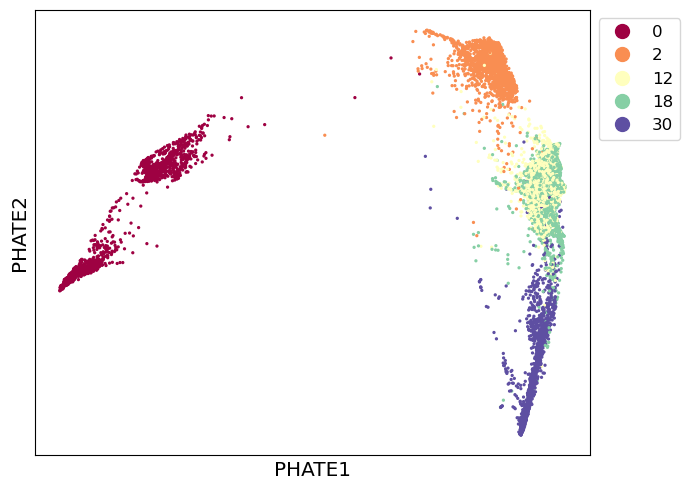

In [71]:
# ================
# Plot the PHATE coordinates
# colored by time point of collection
scprep.plot.scatter2d(df_phate, c=sample_labels, cmap='Spectral', 
                      ticks=False, label_prefix='PHATE',
                      legend_anchor=(1,1), figsize=(7,5))
# ================

#### Gene visualization

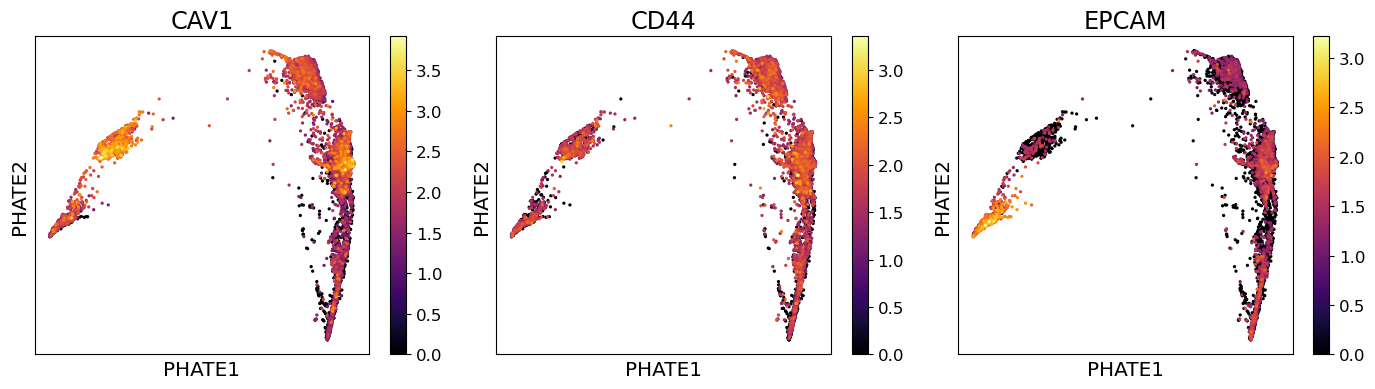

In [165]:
# ================
# Plot three subplots of the PHATE coordinates
genes_for_plotting = ['CAV1','CD44','EPCAM']

fig, axes = plt.subplots(1,3, figsize=(14,4))
axes = axes.flatten()

for gene, ax in zip(genes_for_plotting, axes.flatten()):
    expression = scprep.select.select_cols(data, exact_word=gene)
    
    sort_index = expression.sort_values().index
    
    scprep.plot.scatter2d(df_phate.loc[sort_index], c=expression.loc[sort_index], shuffle=False,
                         title=gene, ticks=None, label_prefix='PHATE', ax=ax)

fig.tight_layout()
# ================

### Discussion

1. We recommend going back and playing aroun with some PHATE parameters. What happens when you change k? What about gamma?

2. In a dataset with trajectories, how can we define the starting and end points?

3. If we want to investigate different markers on cancer, which ones could we look?


# 5. Differentially expressed genes analysis

Since we now can visualize our data in more details, we can also try different analysis.
A classic pipeline involves defining a population and discovering what differentiate the population from others.

Let's try doing that for the population of EPCAM+/CD44+/CAV1+

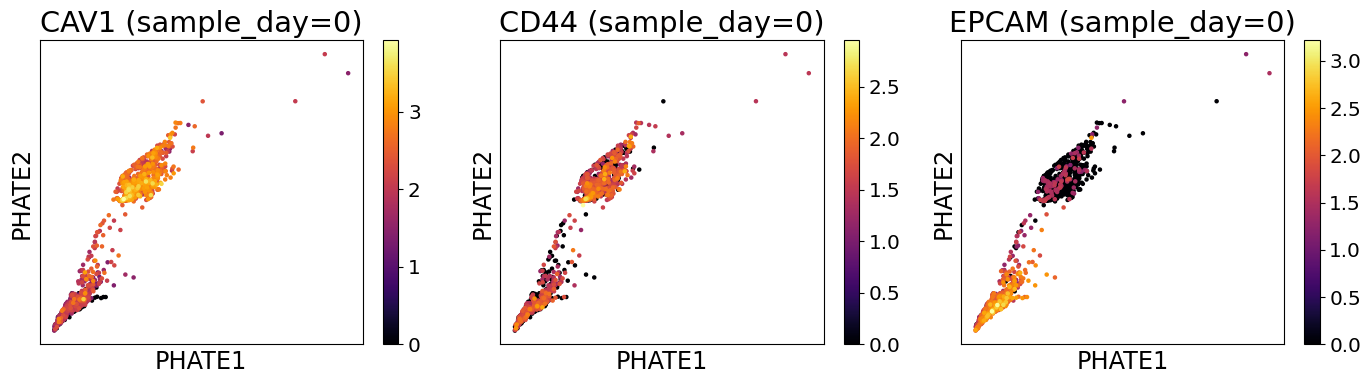

In [202]:
# ================
# Plot three subplots of the PHATE coordinates
# Filter for sample_day = 0 only
genes_for_plotting = ['CAV1','CD44','EPCAM']

# Filter data for sample_day = 0
day0_mask = (sample_labels == 0)
data_day0 = data.loc[day0_mask]
df_phate_day0 = df_phate.loc[day0_mask]

fig, axes = plt.subplots(1,3, figsize=(14,4))
axes = axes.flatten()

for gene, ax in zip(genes_for_plotting, axes.flatten()):
    expression = scprep.select.select_cols(data_day0, exact_word=gene)
    
    sort_index = expression.sort_values().index
    
    scprep.plot.scatter2d(df_phate_day0.loc[sort_index], c=expression.loc[sort_index], shuffle=False,
                         title=f'{gene} (sample_day=0)', ticks=None, label_prefix='PHATE', ax=ax)

fig.tight_layout()
# ================

In [214]:
from scipy import stats

# =============================================================================
# FIND DIFFERENTIALLY EXPRESSED GENES FOR CAV1+ vs CAV1- POPULATION
# =============================================================================
print(f"\nDefining CAV1+ vs CAV1- populations...")

cav1_expr = data_day0['CAV1']

# Define CAV1 threshold using standard deviation
# Method 1: Use mean + 1 standard deviation as threshold for CAV1+
cav1_mean = cav1_expr.mean()
cav1_std = cav1_expr.std()

# Alternative methods using standard deviation:
# Method 2: Use mean + 0.5 standard deviations
# cav1_threshold = cav1_mean + 0.5 * cav1_std

# Method 3: Use mean - 1 standard deviation for CAV1- and mean + 1 standard deviation for CAV1+
# This creates three populations: low, medium, high
cav1_threshold_low = cav1_mean - cav1_std
cav1_threshold_high = cav1_mean + cav1_std

print(f"CAV1 mean: {cav1_mean:.2f}")
print(f"CAV1 std: {cav1_std:.2f}")
print(f"CAV1 threshold (mean + 1 std): {cav1_threshold_high:.2f}")

# Define CAV1+ and CAV1- populations
cav1_positive_mask = cav1_expr >= cav1_threshold_high
cav1_negative_mask = cav1_expr < cav1_threshold_low

n_cav1_positive = cav1_positive_mask.sum()
n_cav1_negative = cav1_negative_mask.sum()

print(f"CAV1+ cells: {n_cav1_positive} ({n_cav1_positive/len(data_day0)*100:.1f}%)")
print(f"CAV1- cells: {n_cav1_negative} ({n_cav1_negative/len(data_day0)*100:.1f}%)")


Defining CAV1+ vs CAV1- populations...
CAV1 mean: 2.03
CAV1 std: 0.91
CAV1 threshold (mean + 1 std): 2.94
CAV1+ cells: 149 (9.1%)
CAV1- cells: 208 (12.6%)


In [222]:
from scipy import stats

expression_df = data
cell_labels = sample_labels

# =============================================================================
# FIND DIFFERENTIALLY EXPRESSED GENES FOR EPCAM+/CD44+ POPULATION
# =============================================================================
# Define EPCAM+/CD44+ population based on expression thresholds
print(f"\nDefining EPCAM+/CD44+ population...")


epcam_expr = expression_df['EPCAM']
cd44_expr = expression_df['CD44' ]

# Define high expression thresholds (you can adjust these)
# Method 1: Use percentile thresholds (e.g., top 25% for each gene)
epcam_threshold = np.percentile(epcam_expr, 75)  # Top 25%
cd44_threshold = np.percentile(cd44_expr, 75)   # Top 25%

# Method 2: Alternative - use mean + std as threshold
# epcam_threshold = epcam_expr.mean() + epcam_expr.std()
# cd44_threshold = cd44_expr.mean() + cd44_expr.std()

print(f"EPCAM threshold (75th percentile): {epcam_threshold:.2f}")
print(f"CD44 threshold (75th percentile): {cd44_threshold:.2f}")

# Define EPCAM+/CD44+ population
epcam_high_mask = epcam_expr >= epcam_threshold
cd44_high_mask = cd44_expr >= cd44_threshold
target_mask = epcam_high_mask & cd44_high_mask
other_mask = ~target_mask

n_epcam_cd44_high = target_mask.sum()
print(f"EPCAM+/CD44+ cells: {n_epcam_cd44_high} ({n_epcam_cd44_high/len(expression_df)*100:.1f}%)")

target_subpopulation = 'EPCAM+/CD44+'
print(f"Finding differential genes for: {target_subpopulation}")

# Parameters for DEG analysis
top_n_genes = 20
min_pct = 0.1
logfc_threshold = 0.25

target_cells = expression_df[target_mask]
other_cells = expression_df[other_mask]

deg_results = []

for gene in expression_df.columns:
    target_expr = target_cells[gene]
    other_expr = other_cells[gene]
    
    # Calculate statistics
    target_mean = target_expr.mean()
    other_mean = other_expr.mean()
    logfc = np.log2((target_mean + 1) / (other_mean + 1))
    
    # Calculate percentage of expressing cells
    target_pct = (target_expr > 0).sum() / len(target_expr)
    other_pct = (other_expr > 0).sum() / len(other_expr)
    

    stat, pval = stats.mannwhitneyu(target_expr, other_expr, alternative='two-sided')
    
    # Filter based on criteria
    if target_pct >= min_pct and abs(logfc) >= logfc_threshold:
        deg_results.append({
            'gene': gene,
            'logfc': logfc,
            'pval': pval,
            'target_pct': target_pct,
            'other_pct': other_pct,
            'target_mean': target_mean,
            'other_mean': other_mean
        })

# Create DataFrame and sort by p-value
deg_df = pd.DataFrame(deg_results)
deg_df = deg_df.sort_values('pval').head(top_n_genes)

print(f"Found {len(deg_df)} differential genes")
print("\nTop 10 differential genes:")
print(deg_df[['gene', 'logfc', 'pval', 'target_pct']].head(10))


Defining EPCAM+/CD44+ population...
EPCAM threshold (75th percentile): 1.15
CD44 threshold (75th percentile): 1.55
EPCAM+/CD44+ cells: 688 (5.6%)
Finding differential genes for: EPCAM+/CD44+
Found 20 differential genes

Top 10 differential genes:
       gene     logfc           pval  target_pct
3     EPCAM  0.936620   0.000000e+00    1.000000
17     CD44  0.606517  2.875322e-287    1.000000
28     KLK5  0.352152   8.306991e-79    0.186047
25    KRT19  0.586562   8.590584e-75    0.549419
10     NPR3  0.272108   1.268929e-53    0.164244
1   TACSTD2  0.385476   2.239350e-50    0.351744
12    CLDN3  0.364116   5.684563e-47    0.402616
22     KRT7  0.328884   2.045636e-44    0.805233
27   SPINT2  0.293221   8.769334e-43    0.744186
18    CCND1  0.267207   2.519676e-39    0.805233


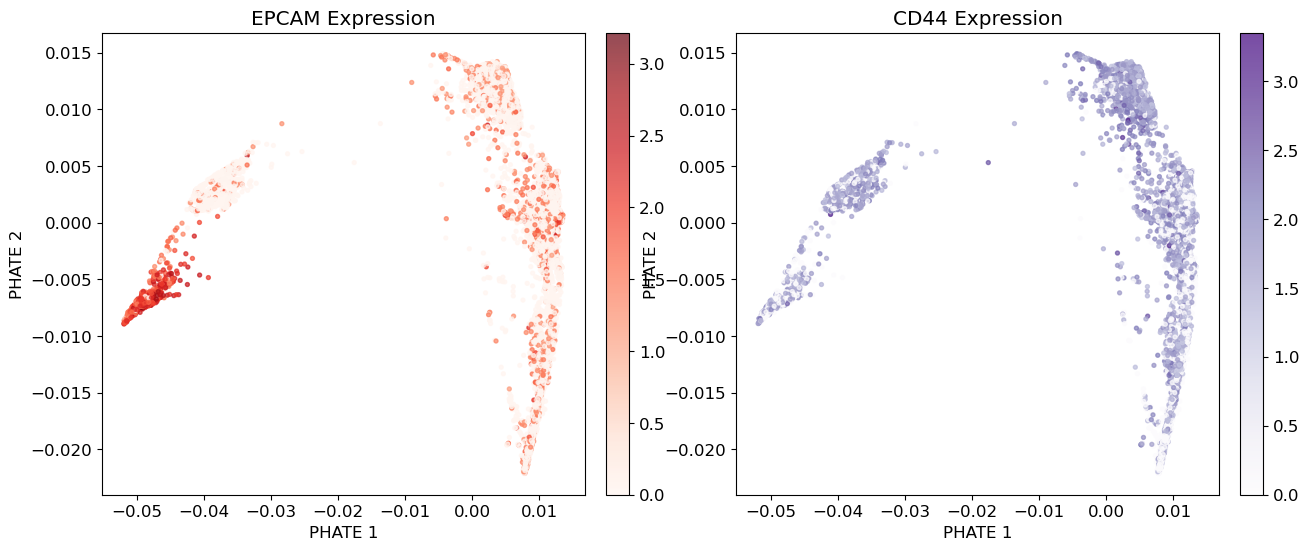

In [223]:
# =============================================================================
# VISUALIZATIONS
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: EPCAM expression
epcam_scatter = axes[0].scatter(
    data_phate[:, 0], 
    data_phate[:, 1],
    c=epcam_expr, 
    s=8, 
    cmap='Reds',
    alpha=0.7
)
axes[0].set_xlabel('PHATE 1')
axes[0].set_ylabel('PHATE 2')
axes[0].set_title(f'EPCAM Expression')
plt.colorbar(epcam_scatter, ax=axes[0], fraction=0.046, pad=0.04)

# Plot 2: CD44 expression
cd44_scatter = axes[1].scatter(
    data_phate[:, 0], 
    data_phate[:, 1],
    c=cd44_expr, 
    s=8, 
    cmap='Purples',
    alpha=0.7
)
axes[1].set_xlabel('PHATE 1')
axes[1].set_ylabel('PHATE 2')
axes[1].set_title(f'CD44 Expression')
plt.colorbar(cd44_scatter, ax=axes[1], fraction=0.046, pad=0.04)

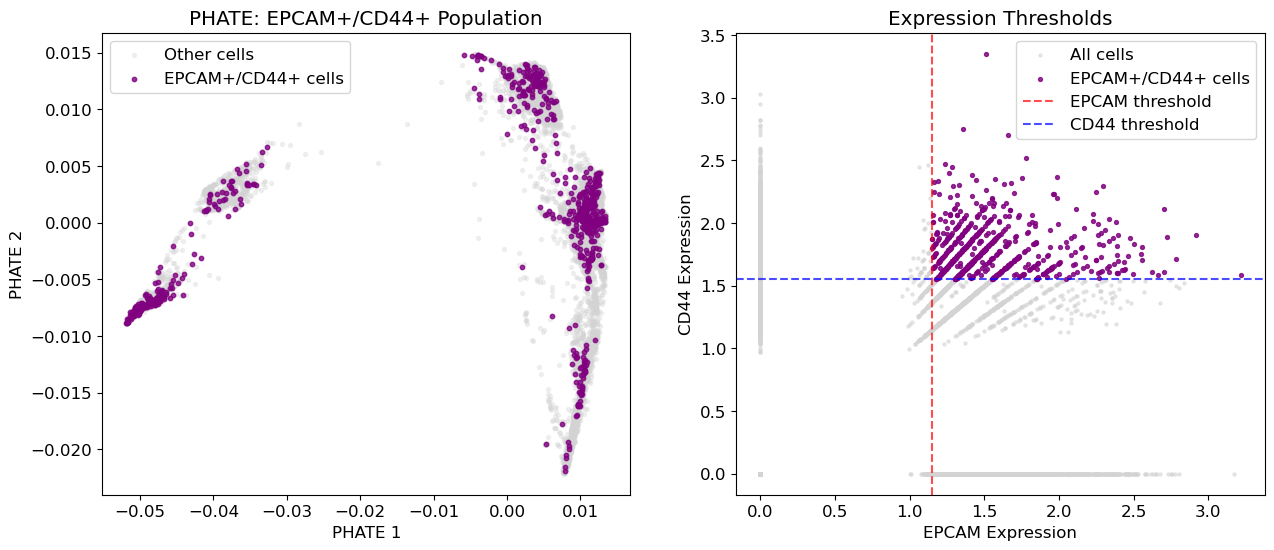

In [226]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 3: EPCAM+/CD44+ population highlighted
axes[0].scatter(
    data_phate[~target_mask, 0], 
    data_phate[~target_mask, 1],
    c='lightgray', 
    s=8, 
    alpha=0.3,
    label='Other cells'
)
axes[0].scatter(
    data_phate[target_mask, 0], 
    data_phate[target_mask, 1],
    c='purple', 
    s=10, 
    alpha=0.8,
    label=f'{target_subpopulation} cells'
)
axes[0].set_xlabel('PHATE 1')
axes[0].set_ylabel('PHATE 2')
axes[0].set_title(f'PHATE: {target_subpopulation} Population')
axes[0].legend()

# Plot 4: Show expression thresholds as scatter plot
axes[1].scatter(epcam_expr, cd44_expr, c='lightgray', s=5, alpha=0.5, label='All cells')
axes[1].scatter(epcam_expr[target_mask], cd44_expr[target_mask], 
                  c='purple', s=8, alpha=0.8, label=f'{target_subpopulation} cells')
axes[1].axvline(x=epcam_threshold, color='red', linestyle='--', alpha=0.7, label=f'EPCAM threshold')
axes[1].axhline(y=cd44_threshold, color='blue', linestyle='--', alpha=0.7, label=f'CD44 threshold')
axes[1].set_xlabel(f'EPCAM Expression')
axes[1].set_ylabel(f'CD44 Expression')
axes[1].set_title('Expression Thresholds')
axes[1].legend()


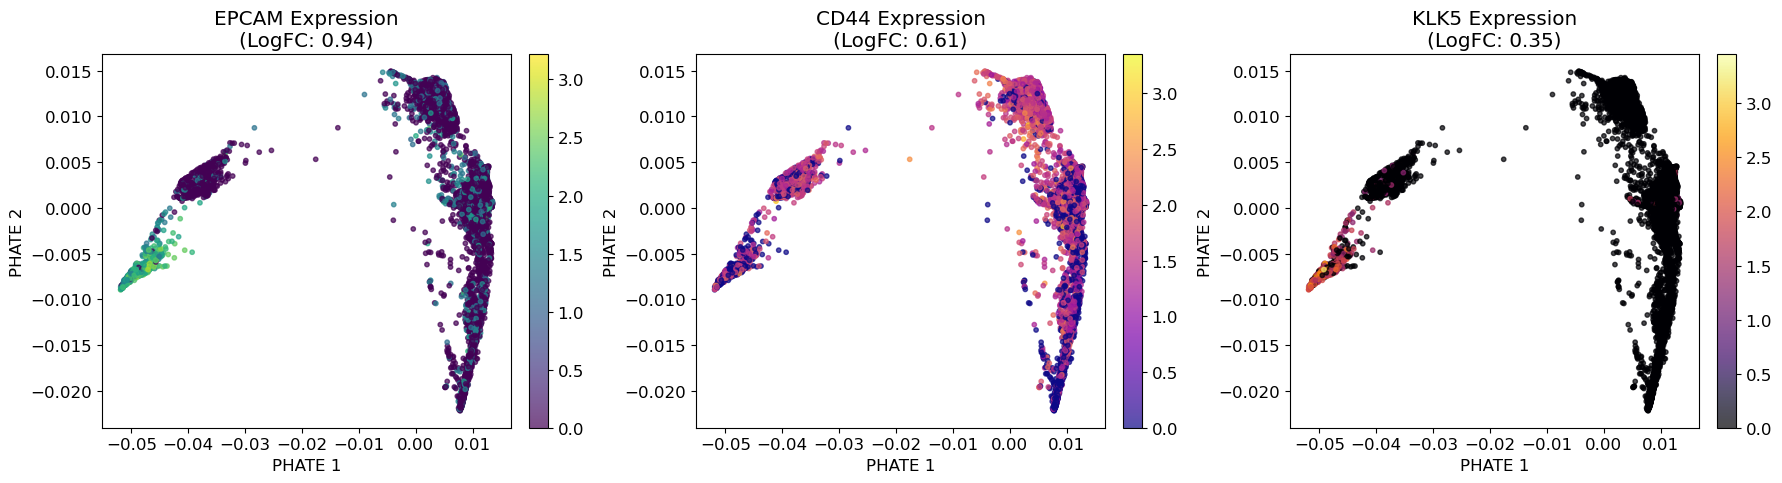

In [227]:
# 2. Gene expression plots for top DEGs
if len(deg_df) >= 3:
    top_3_genes = deg_df.head(3)['gene'].values
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    cmaps = ['viridis', 'plasma', 'inferno']
    
    for i, gene in enumerate(top_3_genes):
        gene_expr = expression_df[gene].values
        
        scatter = axes[i].scatter(
            data_phate[:, 0], 
            data_phate[:, 1],
            c=gene_expr, 
            s=10, 
            cmap=cmaps[i],
            alpha=0.7
        )
        
        axes[i].set_xlabel('PHATE 1')
        axes[i].set_ylabel('PHATE 2')
        axes[i].set_title(f'{gene} Expression\n(LogFC: {deg_df[deg_df.gene==gene].iloc[0].logfc:.2f})')
        plt.colorbar(scatter, ax=axes[i], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()


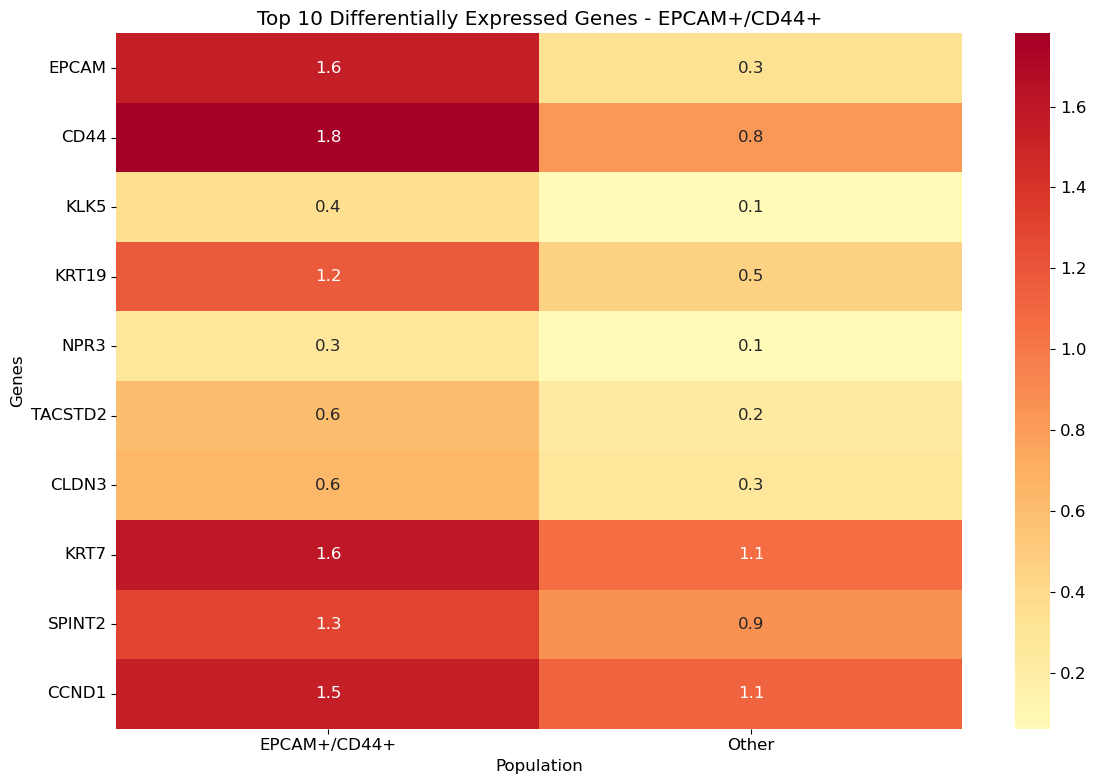

In [235]:
# 3. Heatmap showing expression patterns

top_genes = deg_df.head(10)['gene'].values

# Create binary labels for EPCAM+/CD44+ vs others
population_labels = pd.Series(
    ['Other'] * len(expression_df),
    index=expression_df.index
)
population_labels[target_mask] = target_subpopulation


# Calculate mean expression for each population
mean_expr_data = []
for pop in [target_subpopulation, 'Other']:
    pop_mask = population_labels == pop
    pop_mean = expression_df[pop_mask][top_genes].mean()
    mean_expr_data.append(pop_mean)

mean_expr_df = pd.DataFrame(mean_expr_data, index=[target_subpopulation, 'Other'])

plt.figure(figsize=(12, 8))
sns.heatmap(mean_expr_df.T, annot=True, cmap='RdYlBu_r', center=0, fmt='.1f')
plt.title(f'Top 10 Differentially Expressed Genes - {target_subpopulation}')
plt.xlabel('Population')
plt.ylabel('Genes')
plt.tight_layout()
plt.show()

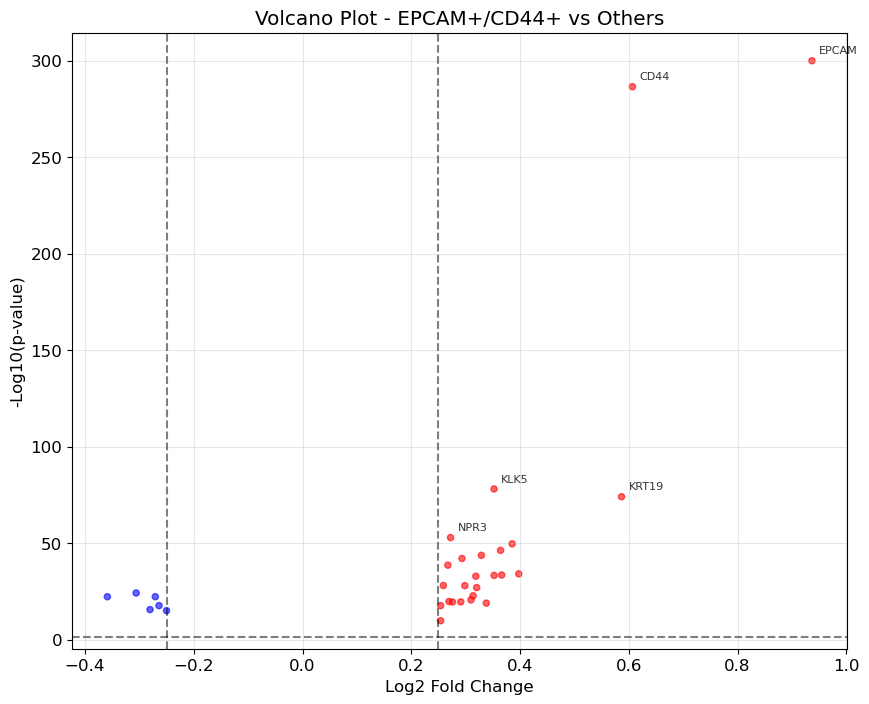

In [236]:
# 4. Volcano plot
if len(deg_results) > 0:
    all_deg_df = pd.DataFrame(deg_results)
    
    plt.figure(figsize=(10, 8))
    
    # Calculate -log10(p-value)
    neg_log_pval = -np.log10(all_deg_df['pval'] + 1e-300)  # Add small value to avoid log(0)
    
    # Color points based on significance and fold change
    colors = ['gray'] * len(all_deg_df)
    for i, (_, row) in enumerate(all_deg_df.iterrows()):
        if row['pval'] < 0.05 and abs(row['logfc']) > logfc_threshold:
            colors[i] = 'red' if row['logfc'] > 0 else 'blue'
    
    plt.scatter(all_deg_df['logfc'], neg_log_pval, c=colors, alpha=0.6, s=20)
    
    # Add significance lines
    plt.axhline(y=-np.log10(0.05), color='black', linestyle='--', alpha=0.5)
    plt.axvline(x=logfc_threshold, color='black', linestyle='--', alpha=0.5)
    plt.axvline(x=-logfc_threshold, color='black', linestyle='--', alpha=0.5)
    
    # Label top genes
    for _, row in deg_df.head(5).iterrows():
        plt.annotate(row['gene'], 
                    (row['logfc'], -np.log10(row['pval'] + 1e-300)),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=8, alpha=0.8)
    
    plt.xlabel('Log2 Fold Change')
    plt.ylabel('-Log10(p-value)')
    plt.title(f'Volcano Plot - {target_subpopulation} vs Others')
    plt.grid(True, alpha=0.3)
    plt.show()

In [237]:
print("\n" + "="*50)
print("ANALYSIS COMPLETE")
print("="*50)
print(f"Target population: {target_subpopulation}")
print(f"Population size: {n_epcam_cd44_high} cells ({n_epcam_cd44_high/len(expression_df)*100:.1f}%)")
print(f"EPCAM threshold: {epcam_threshold:.2f}")
print(f"CD44 threshold: {cd44_threshold:.2f}")
print(f"Total differential genes found: {len(deg_df)}")
if len(deg_df) > 0:
    print(f"Top gene: {deg_df.iloc[0]['gene']} (LogFC: {deg_df.iloc[0]['logfc']:.2f}, p-val: {deg_df.iloc[0]['pval']:.2e})")

# Additional analysis: Show EPCAM/CD44 expression statistics
print(f"\nEPCAM/CD44 Expression Statistics:")
print(f"EPCAM - Mean: {epcam_expr.mean():.2f}, Std: {epcam_expr.std():.2f}")
print(f"CD44 - Mean: {cd44_expr.mean():.2f}, Std: {cd44_expr.std():.2f}")
print(f"EPCAM+/CD44+ - Mean EPCAM: {epcam_expr[target_mask].mean():.2f}")
print(f"EPCAM+/CD44+ - Mean CD44: {cd44_expr[target_mask].mean():.2f}")


ANALYSIS COMPLETE
Target population: EPCAM+/CD44+
Population size: 688 cells (5.6%)
EPCAM threshold: 1.15
CD44 threshold: 1.55
Total differential genes found: 20
Top gene: EPCAM (LogFC: 0.94, p-val: 0.00e+00)

EPCAM/CD44 Expression Statistics:
EPCAM - Mean: 0.40, Std: 0.69
CD44 - Mean: 0.88, Std: 0.79
EPCAM+/CD44+ - Mean EPCAM: 1.55
EPCAM+/CD44+ - Mean CD44: 1.78
